# Violent Crime Capstone

This notebook:
- Adds square footage information from the census bureau
- Calculates and visualizes population density
- save as "capstone_count_rate_density.csv"

In [2]:
import pandas as pd

df = pd.read_csv("capstone_count_rate_density.csv")
df.head()

,state,metropolitan_nonmetropolitan,county,violent_crime_count,murder_and_nonnegligent_manslaughter_count,rape_count,robbery_count,aggravated_assault_count,property_crime,burglary,...,robbery_rate,aggravated_assault_rate,county_state,poverty_bin,unemployment_bin,education_bin,GEOID,ALAND,land_area_sq_miles,population_density
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,...,0.000000,76.734449,"Autauga, ALABAMA",Medium-Low,Low,Medium-High,1001,1539631459,594.455055,100.843621
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,...,0.000000,53.848552,"Baldwin, ALABAMA",Low,Low,High,1003,4117781416,1589.884361,155.350292
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,...,0.000000,131.043832,"Bibb, ALABAMA",High,Low,Low,1007,1612188713,622.469569,35.551939
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,...,3.360328,102.490003,"Blount, ALABAMA",Medium-Low,Low,Low,1009,1670259099,644.890671,92.291613
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,...,0.000000,198.983547,"Calhoun, ALABAMA",High,Low,Medium-Low,1015,1569256885,605.893496,191.601330


In [10]:
label_map = {
    "violent_crime_count": "Violent Crime Count",
    "murder_and_nonnegligent_manslaughter_count": "Murder (Nonnegligent) Count",
    "rape_count": "Rape Count",
    "robbery_count": "Robbery Count",
    "aggravated_assault_count": "Aggravated Assault Count",

    "violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)",
    "murder_and_nonnegligent_manslaughter_rate": "Murder (Nonnegligent Manslaughter) Rate",
    "rape_rate": "Rape Rate",
    "robbery_rate": "Robbery Rate",
    "aggravated_assault_rate": "Aggravated Assault Rate",

    "unemployment_pct": "Unemployment Rate (%)",
    "poverty_pct": "Poverty Rate (%)",
    "bachelors_or_higher_pct": "Bachelor's Degree (%)",

    "median_income": "Median Household Income",

    "county": "County",
    "state": "State",
    "county_state": "County State",
    "population_density": "Population Density"
}

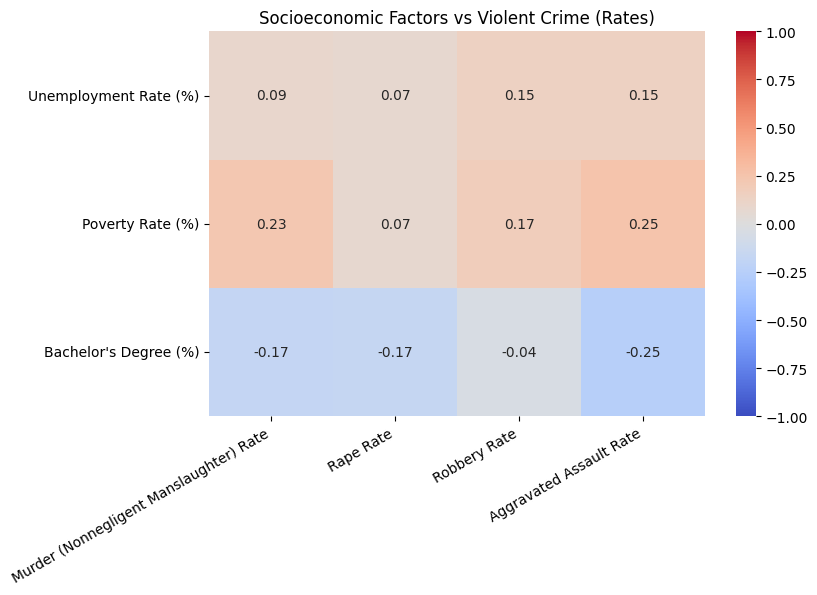

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

predictors = [
    "unemployment_pct",
    "poverty_pct",
    "bachelors_or_higher_pct"
]

crime_rates = [
    "murder_and_nonnegligent_manslaughter_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate"
]

# correlation matrix
corr = df[predictors + crime_rates].corr()
subset = corr.loc[predictors, crime_rates]

subset_plot = subset.rename(index=label_map, columns=label_map)

plt.figure(figsize=(8,5))

sns.heatmap(
    subset_plot,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.title("Socioeconomic Factors vs Violent Crime (Rates)")

plt.show()

In [34]:
import statsmodels.api as sm

X = df[["poverty_pct", "unemployment_pct", "bachelors_or_higher_pct"]]
X = sm.add_constant(X)
y = df["violent_crime_rate_per_100k"]

model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     violent_crime_rate_per_100k   R-squared:                       0.086
Model:                                     OLS   Adj. R-squared:                  0.085
Method:                          Least Squares   F-statistic:                     58.16
Date:                         Wed, 15 Apr 2026   Prob (F-statistic):           6.27e-36
Time:                                 11:25:38   Log-Likelihood:                -11052.
No. Observations:                         1858   AIC:                         2.211e+04
Df Residuals:                             1854   BIC:                         2.213e+04
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

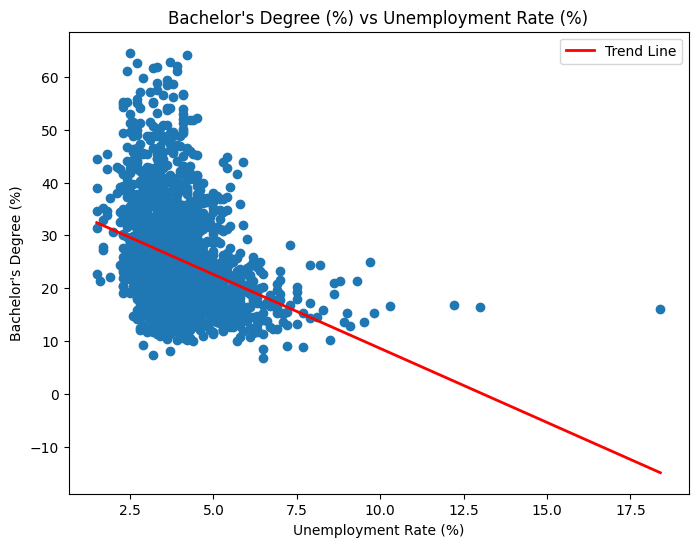

In [15]:
import matplotlib.pyplot as plt
import numpy as np

x = "unemployment_pct"
y = "bachelors_or_higher_pct"

plt.figure(figsize=(8, 6))

# Scatter
plt.scatter(df[x], df[y])

# Create trend line
z = np.polyfit(df[x], df[y], 1)
p = np.poly1d(z)

# Plot trend line
x_vals = np.linspace(df[x].min(), df[x].max(), 100)
plt.plot(x_vals, p(x_vals), color="red", linewidth=2, label="Trend Line")
plt.legend()

# Labels
plt.xlabel(label_map[x])
plt.ylabel(label_map[y])
plt.title(f"{label_map[y]} vs {label_map[x]}")

plt.show()

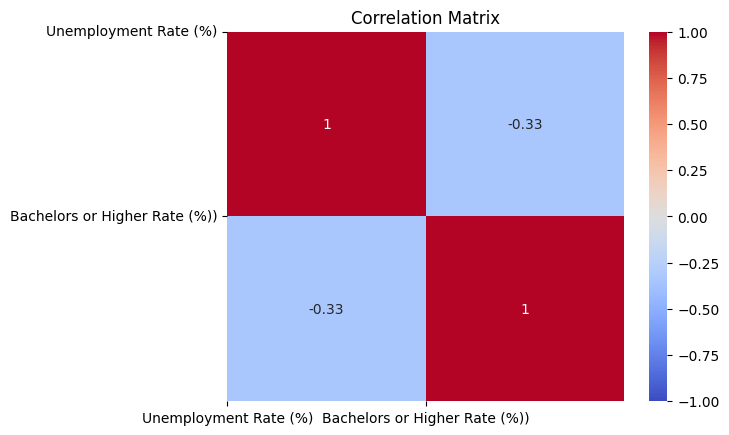

In [16]:
import seaborn as sns

corr = df[["unemployment_pct", "bachelors_or_higher_pct"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

labels = ["Unemployment Rate (%)", "Bachelors or Higher Rate (%))"]

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, ha="center")
plt.yticks(ticks=range(len(labels)), labels=labels, rotation=0, va="center")

plt.title("Correlation Matrix")

plt.show()

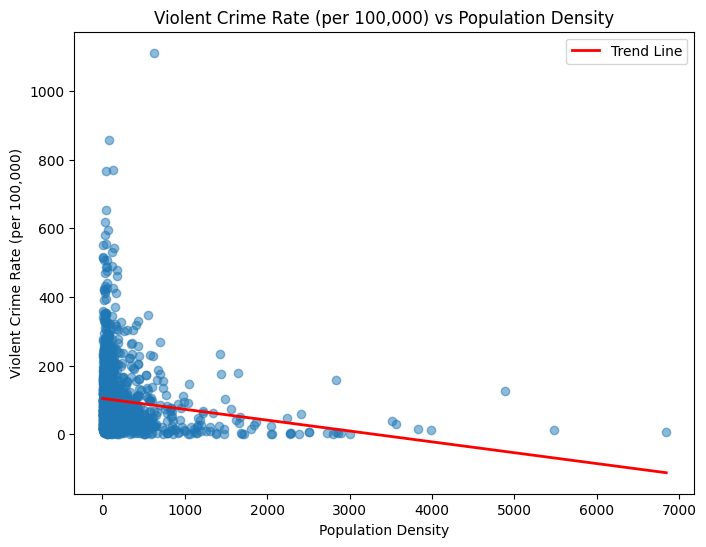

In [18]:
import matplotlib.pyplot as plt
import numpy as np

x = "population_density"
y = "violent_crime_rate_per_100k"

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(df[x], df[y], alpha=0.5)

# Trend
z = np.polyfit(df[x], df[y], 1)
p = np.poly1d(z)

x_vals = np.linspace(df[x].min(), df[x].max(), 100)
plt.plot(x_vals, p(x_vals), color="red", linewidth=2, label="Trend Line")
plt.legend()

# Labels
plt.xlabel(label_map.get(x, x))
plt.ylabel(label_map.get(y, y))
plt.title(f"{label_map.get(y, y)} vs {label_map.get(x, x)}")

plt.show()

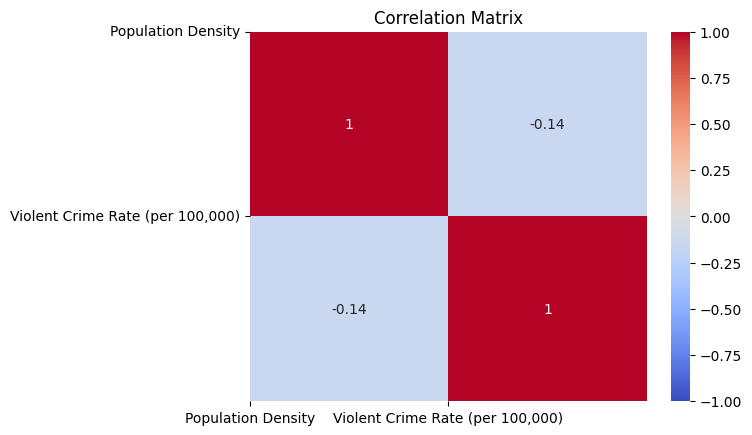

In [17]:
import seaborn as sns

corr = df[["population_density", "violent_crime_rate_per_100k"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

labels = ["Population Density", "Violent Crime Rate (per 100,000)"]

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, ha="center")
plt.yticks(ticks=range(len(labels)), labels=labels, rotation=0, va="center")

plt.title("Correlation Matrix")

plt.show()

In [20]:
import plotly.express as px

fig = px.choropleth(
    df,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="violent_crime_rate_per_100k",
    color_continuous_scale="Reds",
    range_color=(0, 500),
    scope="usa",
    hover_name="county",
    hover_data={
        "state": True,
        "violent_crime_rate_per_100k": ":.2f",
        "fips": False
    },
    labels={"violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)"},
    title="Violent Crime Rate by County"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0, "t":50, "l":0, "b":0})

fig.show()

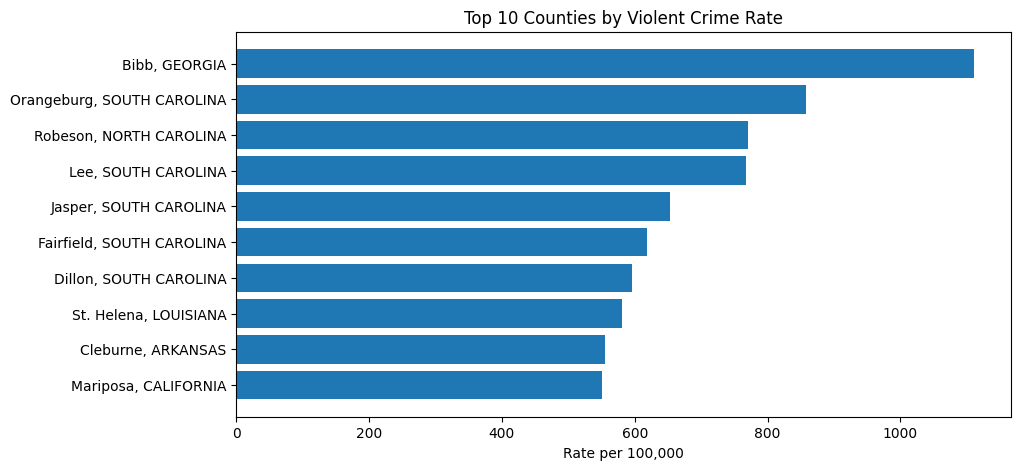

In [21]:
top10 = df.nlargest(10, "violent_crime_rate_per_100k")

plt.figure(figsize=(10,5))
plt.barh(top10["county_state"], top10["violent_crime_rate_per_100k"])
plt.gca().invert_yaxis()
plt.title("Top 10 Counties by Violent Crime Rate")
plt.xlabel("Rate per 100,000")
plt.show()

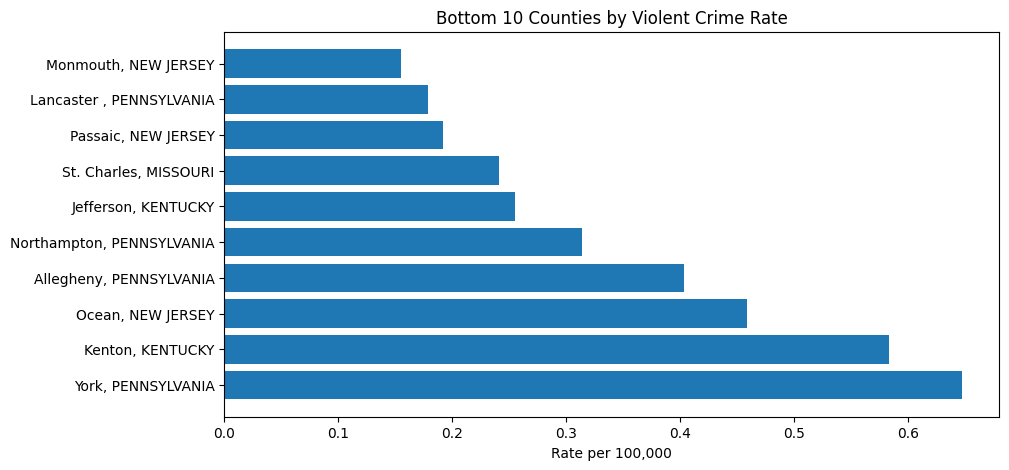

In [23]:
bottom10 = df.nsmallest(10, "violent_crime_rate_per_100k")

plt.figure(figsize=(10,5))
plt.barh(bottom10["county_state"], bottom10["violent_crime_rate_per_100k"])
plt.gca().invert_yaxis()
plt.title("Bottom 10 Counties by Violent Crime Rate")
plt.xlabel("Rate per 100,000")
plt.show()

In [24]:
df.groupby("poverty_bin")["violent_crime_rate_per_100k"].mean()

poverty_bin
High           134.537143
Low             68.897987
Medium-High    105.197551
Medium-Low      86.406536
Name: violent_crime_rate_per_100k, dtype: float64

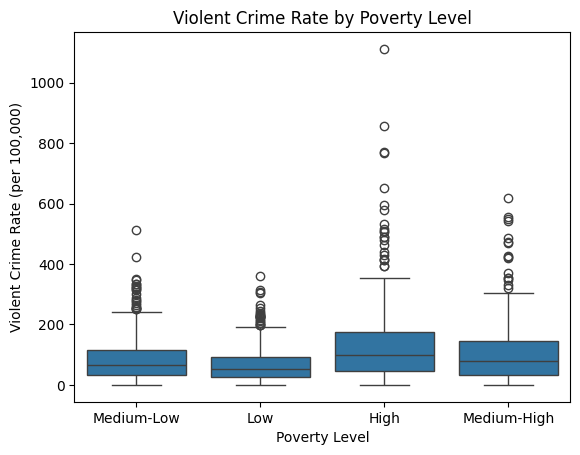

In [25]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="poverty_bin",
    y="violent_crime_rate_per_100k"
)
plt.xlabel("Poverty Level")
plt.ylabel("Violent Crime Rate (per 100,000)")
plt.title("Violent Crime Rate by Poverty Level")
plt.show()

In [26]:
df.groupby("unemployment_bin")["violent_crime_rate_per_100k"].mean()

unemployment_bin
High           123.365207
Low             76.574472
Medium-High     98.597736
Medium-Low      99.103013
Name: violent_crime_rate_per_100k, dtype: float64

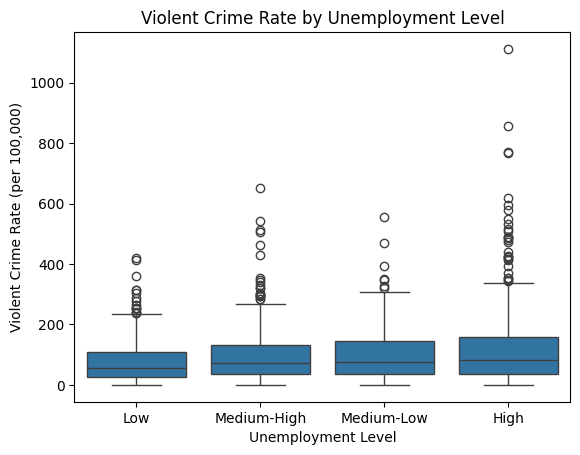

In [27]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="unemployment_bin",
    y="violent_crime_rate_per_100k"
)
plt.xlabel("Unemployment Level")
plt.ylabel("Violent Crime Rate (per 100,000)")
plt.title("Violent Crime Rate by Unemployment Level")
plt.show()

In [28]:
df.groupby("education_bin")["violent_crime_rate_per_100k"].mean()

education_bin
High            66.646556
Low            135.339519
Medium-High     86.941396
Medium-Low     104.828638
Name: violent_crime_rate_per_100k, dtype: float64

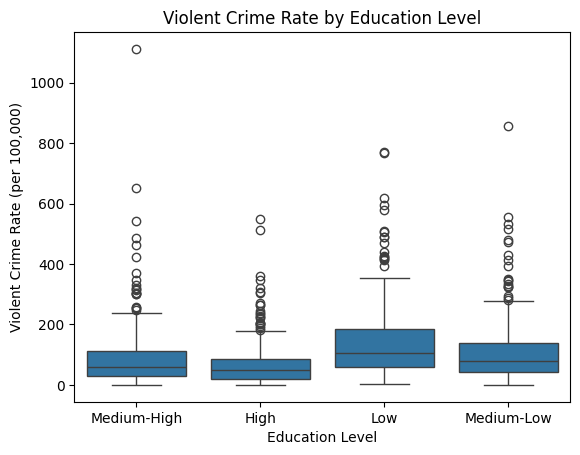

In [29]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="education_bin",
    y="violent_crime_rate_per_100k"
)
plt.xlabel("Education Level")
plt.ylabel("Violent Crime Rate (per 100,000)")
plt.title("Violent Crime Rate by Education Level")
plt.show()

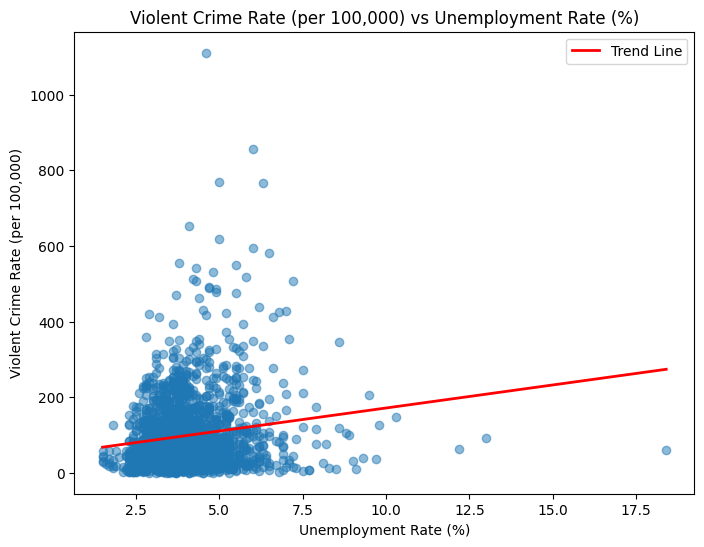

In [30]:
import matplotlib.pyplot as plt
import numpy as np

x = "unemployment_pct"
y = "violent_crime_rate_per_100k"

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(df[x], df[y], alpha=0.5)

# Trend
z = np.polyfit(df[x], df[y], 1)
p = np.poly1d(z)

x_vals = np.linspace(df[x].min(), df[x].max(), 100)
plt.plot(x_vals, p(x_vals), color="red", linewidth=2, label="Trend Line")
plt.legend()

# Labels
plt.xlabel(label_map.get(x, x))
plt.ylabel(label_map.get(y, y))
plt.title(f"{label_map.get(y, y)} vs {label_map.get(x, x)}")

plt.show()

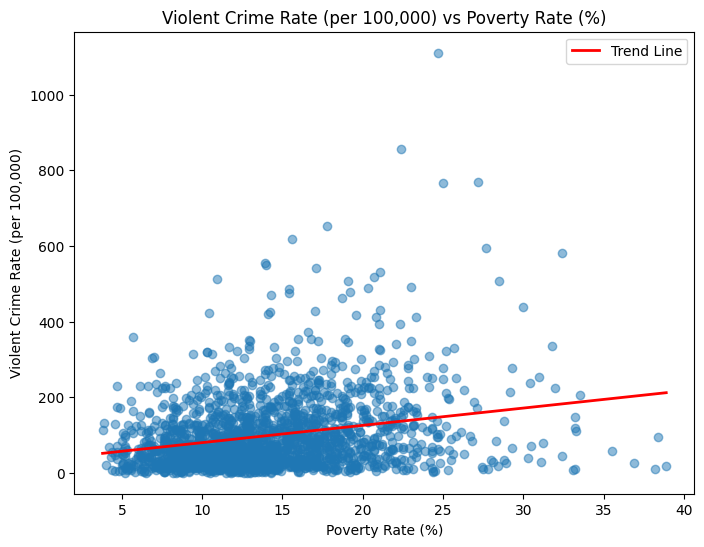

In [33]:
import matplotlib.pyplot as plt
import numpy as np

x = "poverty_pct"
y = "violent_crime_rate_per_100k"

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(df[x], df[y], alpha=0.5)

# Trend
z = np.polyfit(df[x], df[y], 1)
p = np.poly1d(z)

x_vals = np.linspace(df[x].min(), df[x].max(), 100)
plt.plot(x_vals, p(x_vals), color="red", linewidth=2, label="Trend Line")
plt.legend()

# Labels
plt.xlabel(label_map.get(x, x))
plt.ylabel(label_map.get(y, y))
plt.title(f"{label_map.get(y, y)} vs {label_map.get(x, x)}")

plt.show()

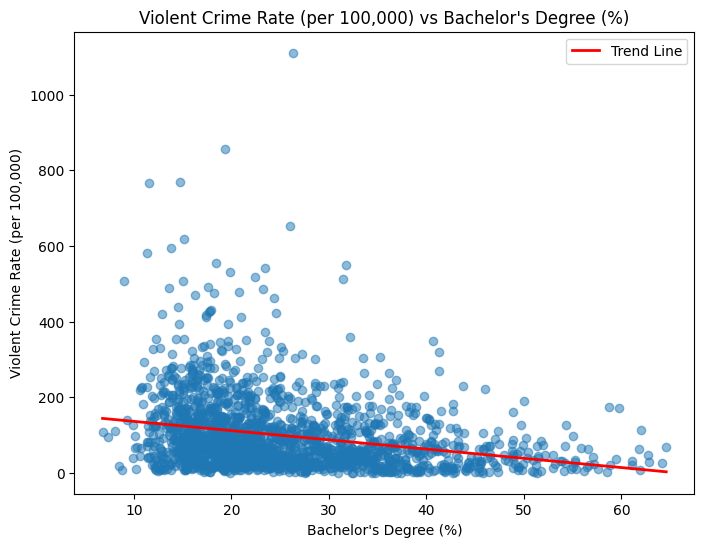

In [32]:
import matplotlib.pyplot as plt
import numpy as np

x = "bachelors_or_higher_pct"
y = "violent_crime_rate_per_100k"

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(df[x], df[y], alpha=0.5)

# Trend
z = np.polyfit(df[x], df[y], 1)
p = np.poly1d(z)

x_vals = np.linspace(df[x].min(), df[x].max(), 100)
plt.plot(x_vals, p(x_vals), color="red", linewidth=2, label="Trend Line")
plt.legend()

# Labels
plt.xlabel(label_map.get(x, x))
plt.ylabel(label_map.get(y, y))
plt.title(f"{label_map.get(y, y)} vs {label_map.get(x, x)}")

plt.show()